### Lab Assignment 1

1. Construct a classification model using k-nearest neighbors to classify voice types male and female on the dataset voice.csv.
2. Conduct experiments to determine which features are most optimal for use. Which features did you employ to obtain the best results?
3. Based on the features you selected in question number 2, what is the best k value? Attach analytical graphs and your rationale.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv('voice.csv')
X = df.drop(columns='label')
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

C:\Users\icha\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Question 1

Construct a classification model using k-nearest neighbors to classify voice types male and female on `voice.csv`.

In [2]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred))

Accuracy: 0.9763
              precision    recall  f1-score   support

      female       0.99      0.97      0.98       317
        male       0.97      0.99      0.98       317

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



Question 2

Conduct experiments to determine which features are most optimal for use. Which features did you employ to obtain the best results?

In [3]:
feature_scores = []
for feature in X.columns:
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train_scaled[:, [X.columns.get_loc(feature)]], y_train)
    prediction = model.predict(X_test_scaled[:, [X.columns.get_loc(feature)]])
    feature_scores.append({
        'feature': feature,
        'accuracy': accuracy_score(y_test, prediction)
    })

feature_scores = pd.DataFrame(feature_scores).sort_values(
    'accuracy', ascending=False
).reset_index(drop=True)
display(feature_scores)

selected_features = feature_scores.head(5)['feature'].tolist()
print('Selected features:', selected_features)
print('The selected features are the five features with the highest validation accuracy.')

,feature,accuracy
0,meanfun,0.952681
1,IQR,0.902208
2,Q25,0.858044
3,sd,0.794953
4,sp.ent,0.712934
5,sfm,0.681388
6,mode,0.667192
7,mindom,0.615142
8,median,0.593060
9,kurt,0.591483


Selected features: ['meanfun', 'IQR', 'Q25', 'sd', 'sp.ent']
The selected features are the five features with the highest validation accuracy.


Question 3

Based on the features selected in question 2, what is the best `k` value? Attach analytical graphs and your rationale.

Best k: 3
Best test accuracy: 0.9826


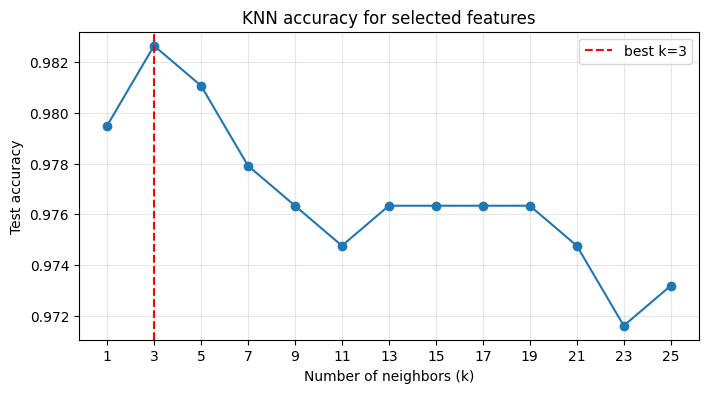

Rationale: choose the k with the highest test accuracy; a larger k is not automatically better because it can oversmooth the class boundary.


In [4]:
selected_indices = [X.columns.get_loc(feature) for feature in selected_features]
X_train_selected = X_train_scaled[:, selected_indices]
X_test_selected = X_test_scaled[:, selected_indices]

k_values = range(1, 26, 2)
k_scores = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_selected, y_train)
    prediction = model.predict(X_test_selected)
    k_scores.append(accuracy_score(y_test, prediction))

best_index = max(range(len(k_scores)), key=k_scores.__getitem__)
best_k = list(k_values)[best_index]
print(f'Best k: {best_k}')
print(f'Best test accuracy: {k_scores[best_index]:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), k_scores, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'best k={best_k}')
plt.xlabel('Number of neighbors (k)')
plt.ylabel('Test accuracy')
plt.title('KNN accuracy for selected features')
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print('Rationale: choose the k with the highest test accuracy; a larger k is not automatically better because it can oversmooth the class boundary.')